In [ ]:
# Mount Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Import Libraries
!pip install lightgbm==4.1.0 h5py

import os
import numpy as np
import pandas as pd
import lightgbm as lgb

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    auc
)
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 50.7 MB/s eta 0:00:00
  Attempting uninstall: lightgbm
    Found existing installation: lightgbm 4.6.0
    Uninstalling lightgbm-4.6.0:
      Successfully uninstalled lightgbm-4.6.0


In [ ]:
# Load and Check file paths
paths = {
    "train": "/content/drive/My Drive/Embedding_Concatenate/Concatenated_Train_embeddings.csv",
    "val":   "/content/drive/My Drive/Embedding_Concatenate/Concatenated_Val_embeddings.csv",
    "test":  "/content/drive/My Drive/Embedding_Concatenate/Concatenated_Test_embeddings.csv"
}

for k,v in paths.items():
    if not os.path.exists(v):
        raise FileNotFoundError(f"Missing: {v}")
print("All files found!")


All files found!


In [ ]:
# Remap 23-class labels → 4-class labels

def map_labels(y):
    y_new = []

    for v in y:
        if v == 0:
            y_new.append(0)         # BENIGN
        elif 1 <= v <= 4:
            y_new.append(1)         # DDoS
        elif 5 <= v <= 18:
            y_new.append(2)         # Zero-Day
        elif 19 <= v <= 22:
            y_new.append(3)         # Malware
        else:
            raise ValueError(f"Invalid original class: {v}")

    return np.array(y_new)


# Load original concatenated CSVs
train_df = pd.read_csv(paths["train"])
val_df   = pd.read_csv(paths["val"])
test_df  = pd.read_csv(paths["test"])

# Apply label remapping
train_df["Label"] = map_labels(train_df["Label"])
val_df["Label"]   = map_labels(val_df["Label"])
test_df["Label"]  = map_labels(test_df["Label"])

# Save the corrected 4-class CSVs
save_dir = "/content/drive/My Drive/Embedding_Concatenate_4Class"
os.makedirs(save_dir, exist_ok=True)

train_df.to_csv(f"{save_dir}/Train_4class.csv", index=False)
val_df.to_csv(f"{save_dir}/Val_4class.csv", index=False)
test_df.to_csv(f"{save_dir}/Test_4class.csv", index=False)

print("Labels mapped to 0–3 and new CSVs saved successfully!")


Labels mapped to 0–3 and new CSVs saved successfully!


In [ ]:
# Split X and y

train_df = pd.read_csv("/content/drive/My Drive/Embedding_Concatenate_4Class/Train_4class.csv")
val_df   = pd.read_csv("/content/drive/My Drive/Embedding_Concatenate_4Class/Val_4class.csv")
test_df  = pd.read_csv("/content/drive/My Drive/Embedding_Concatenate_4Class/Test_4class.csv")

X_train = train_df.drop(columns=["Label"]).values.astype(np.float32)
y_train = train_df["Label"].values.astype(int)

X_val   = val_df.drop(columns=["Label"]).values.astype(np.float32)
y_val   = val_df["Label"].values.astype(int)

X_test  = test_df.drop(columns=["Label"]).values.astype(np.float32)
y_test  = test_df["Label"].values.astype(int)

print("Shapes:")
print("Train:", X_train.shape, y_train.shape)
print("Val:  ", X_val.shape,   y_val.shape)
print("Test: ", X_test.shape,  y_test.shape)

Shapes:
Train: (586532, 384) (586532,)
Val:   (195448, 384) (195448,)
Test:  (195519, 384) (195519,)


In [ ]:
# Prepare for ROC

classes = np.array([0,1,2,3])
n_classes = 4
print("Detected classes ({}): {}".format(n_classes, classes))

y_train_bin = label_binarize(y_train, classes=classes)
y_val_bin   = label_binarize(y_val,   classes=classes)
y_test_bin  = label_binarize(y_test,  classes=classes)

Detected classes (4): [0 1 2 3]


In [ ]:
# -----------------------------
# Train LightGBM (GPU) with early stopping + training time print
# -----------------------------
import time

lgb_train = lgb.Dataset(X_train, label=y_train)
lgb_val   = lgb.Dataset(X_val, label=y_val, reference=lgb_train)

params = {
    "objective": "multiclass",
    "num_class": 4,           # 0=Benign,1=DDoS,2=Zero-Day,3=Malware
    "learning_rate": 0.05,
    "num_leaves": 128,
    "max_depth": 8,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "metric": "multi_logloss",
    "verbose": -1
}

start = time.time()

model = lgb.train(
    params=params,
    train_set=lgb_train,
    num_boost_round=2000,
    valid_sets=[lgb_val],
    callbacks=[
        lgb.early_stopping(stopping_rounds=100),
        lgb.log_evaluation(period=50)
    ]
)

print(f"\nTraining completed in {time.time() - start:.2f} seconds.")


Training until validation scores don't improve for 100 rounds
[50]	valid_0's multi_logloss: 0.403288
[100]	valid_0's multi_logloss: 0.377715
[150]	valid_0's multi_logloss: 0.3744
[200]	valid_0's multi_logloss: 0.374088
[250]	valid_0's multi_logloss: 0.374284
Early stopping, best iteration is:
[197]	valid_0's multi_logloss: 0.374083

Training completed in 193.08 seconds.


In [ ]:
# Save Model
model_dir = "/content/drive/My Drive/Ensemble model training/LightGBM_4 Class"
os.makedirs(model_dir, exist_ok=True)

model.save_model(f"{model_dir}/lightgbm_4class_model.json")
print("Model saved.")


Model saved.


In [ ]:
# Predict on test set and produce classification report

y_proba = model.predict(X_test)       # shape: (n_samples, 4)
y_pred = np.argmax(y_proba, axis=1)

print("\nTEST REPORT:\n")
print(classification_report(y_test, y_pred, digits=4))

cm = confusion_matrix(y_test, y_pred)
print("Confusion matrix:\n", cm)



TEST REPORT:

              precision    recall  f1-score   support

           0     0.3511    0.0013    0.0026     25519
           1     0.7890    1.0000    0.8820     56715
           2     0.9176    1.0000    0.9570    111324
           3     0.8534    0.9704    0.9081      1961

    accuracy                         0.8693    195519
   macro avg     0.7278    0.7429    0.6875    195519
weighted avg     0.8057    0.8693    0.8102    195519

Confusion matrix:
 [[    33  15167   9992    327]
 [     1  56714      0      0]
 [     2      0 111322      0]
 [    58      0      0   1903]]


In [ ]:
# Print Train/Val/Test Reports

def eval_split(name, X, y):
    p = model.predict(X).argmax(axis=1)
    print(f"\n{name} REPORT:")
    print(classification_report(y, p, digits=4))

eval_split("TRAIN", X_train, y_train)
eval_split("VAL", X_val, y_val)
eval_split("TEST", X_test, y_test)


TRAIN REPORT:
              precision    recall  f1-score   support

           0     0.9412    0.0046    0.0091     77336
           1     0.7889    1.0000    0.8820    170147
           2     0.9176    1.0000    0.9570    333922
           3     0.7737    0.9957    0.8708      5127

    accuracy                         0.8687    586532
   macro avg     0.8554    0.7501    0.6797    586532
weighted avg     0.8821    0.8687    0.8095    586532


VAL REPORT:
              precision    recall  f1-score   support

           0     0.2911    0.0009    0.0018     25748
           1     0.7892    1.0000    0.8822     56682
           2     0.9176    1.0000    0.9570    111309
           3     0.7382    0.9684    0.8378      1709

    accuracy                         0.8681    195448
   macro avg     0.6840    0.7423    0.6697    195448
weighted avg     0.7962    0.8681    0.8084    195448


TEST REPORT:
              precision    recall  f1-score   support

           0     0.3511    0.0013


===== Confusion Matrix: Train =====
[[   352  45521  29971   1492]
 [     0 170146      1      0]
 [     0      0 333921      1]
 [    22      0      0   5105]]
Saved: /content/drive/My Drive/Ensemble model training/LightGBM_4 Class/cm_train.png


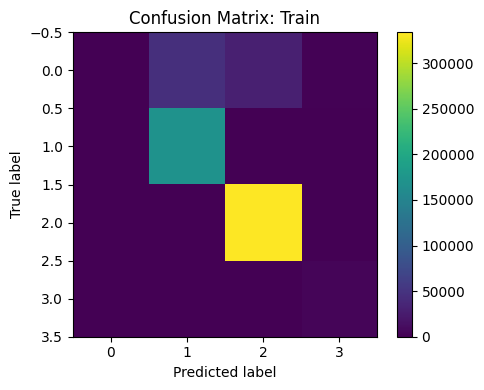


===== Confusion Matrix: Validation =====
[[    23  15143   9997    585]
 [     0  56682      0      0]
 [     2      0 111305      2]
 [    54      0      0   1655]]
Saved: /content/drive/My Drive/Ensemble model training/LightGBM_4 Class/cm_val.png


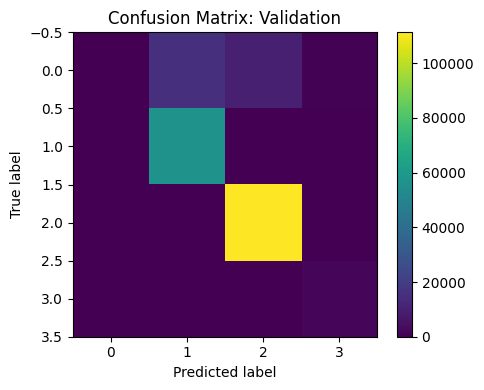


===== Confusion Matrix: Test =====
[[    33  15167   9992    327]
 [     1  56714      0      0]
 [     2      0 111322      0]
 [    58      0      0   1903]]
Saved: /content/drive/My Drive/Ensemble model training/LightGBM_4 Class/cm_test.png


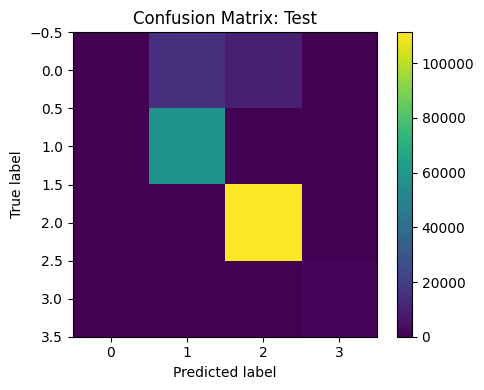

In [ ]:
# Confusion Matrix for Train, Validation, and Test

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm_save_path = "/content/drive/My Drive/Ensemble model training/LightGBM_4 Class"
os.makedirs(cm_save_path, exist_ok=True)

def plot_cm_and_save(cm, title, filename):
    plt.figure(figsize=(5,4))
    plt.imshow(cm, interpolation='nearest')
    plt.title(title)
    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    plt.colorbar()
    plt.tight_layout()

    save_file = f"{cm_save_path}/{filename}"
    plt.savefig(save_file)
    print(f"Saved: {save_file}")

    plt.show()

def generate_cm(name, X, y, filename):
    pred = model.predict(X).argmax(axis=1)
    cm = confusion_matrix(y, pred)
    print(f"\n===== Confusion Matrix: {name} =====")
    print(cm)
    plot_cm_and_save(cm, f"Confusion Matrix: {name}", filename)

# Train
generate_cm("Train", X_train, y_train, "cm_train.png")

# Validation
generate_cm("Validation", X_val, y_val, "cm_val.png")

# Test
generate_cm("Test", X_test, y_test, "cm_test.png")

Per-class AUCs:
 Class 0: AUC = 0.6282
 Class 1: AUC = 0.9452
 Class 2: AUC = 0.9405
 Class 3: AUC = 0.9990
Macro AUC: 0.8782033828178574


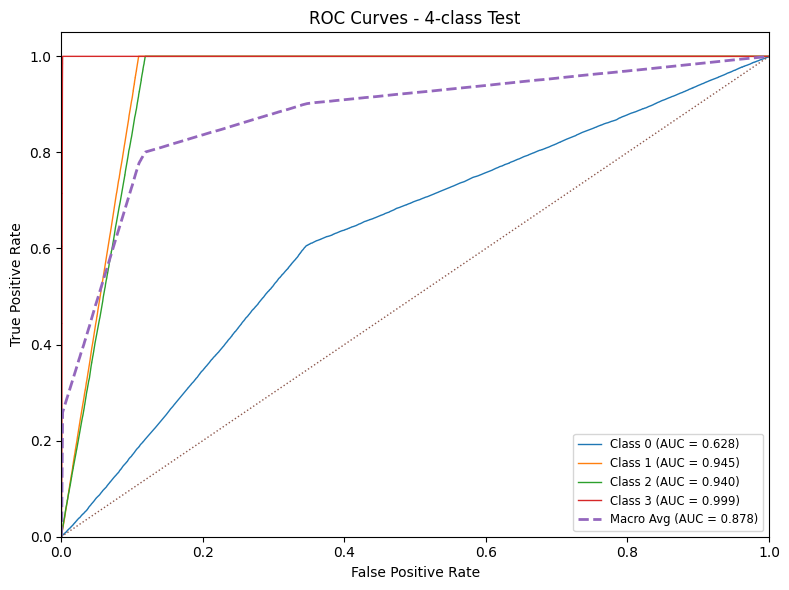

ROC curve saved to: /content/drive/My Drive/Ensemble model training/LightGBM_4 Class/roc_curve_test.png


In [ ]:
# ROC curves & AUC (one-vs-rest, per-class + macro AUC)

y_proba = model.predict(X_test)  # predicted probabilities

fpr = {}
tpr = {}
roc_auc = {}

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Macro-average AUC
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))
mean_tpr = np.zeros_like(all_fpr)

for i in range(n_classes):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
mean_tpr /= n_classes

fpr["macro"] = all_fpr
tpr["macro"] = mean_tpr
roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])

print("Per-class AUCs:")
for i in range(n_classes):
    print(f" Class {classes[i]}: AUC = {roc_auc[i]:.4f}")
print("Macro AUC:", roc_auc["macro"])

# Plot ROC
plt.figure(figsize=(8,6))

for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], linewidth=1,
             label=f"Class {classes[i]} (AUC = {roc_auc[i]:.3f})")

plt.plot(fpr["macro"], tpr["macro"], linewidth=2, linestyle='--',
         label=f"Macro Avg (AUC = {roc_auc['macro']:.3f})")

plt.plot([0,1], [0,1], linewidth=1, linestyle=':')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves - 4-class Test")
plt.legend(loc="lower right", fontsize='small')
plt.tight_layout()

roc_path = "/content/drive/My Drive/Ensemble model training/LightGBM_4 Class/roc_curve_test.png"
plt.savefig(roc_path)
plt.show()

print("ROC curve saved to:", roc_path)
